In [ ]:

# Cell 1 — Imports, Data & Final Model


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib

# Load cleaned and engineered data
df = pd.read_csv("../data/processed/customer_churn_cleaned.csv")

# Load final trained model
final_model = joblib.load("../models/final_churn_model.pkl")

print("Dataset Shape:", df.shape)
print("Final Model:", type(final_model.named_steps["model"]).__name__)

display(df.head())

c:\Users\saura\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset Shape: (100000, 19)
Final Model: LogisticRegression


,customer_id,age,gender,city,acquisition_channel,subscription_plan,payment_method,signup_date,tenure_months,orders_count,monthly_spend,discount_usage_rate,support_tickets,satisfaction_score,last_order_date,churn,recency_days,orders_per_month,support_tickets_per_month
0,178303,23.0,Male,Ahmedabad,Referral,Standard,Wallet,2023-10-12,27,7,14545.09,0.666,1,5,2025-09-21,0,100,0.259259,0.037037
1,166465,48.0,Male,Mumbai,Social Media,Premium,Debit Card,2023-12-14,24,2,4134.45,0.173,3,4,2025-11-29,0,31,0.083333,0.125000
2,193228,31.0,Female,Delhi,Paid Ads,Basic,Debit Card,2024-02-25,22,1,776.62,0.499,0,5,2025-05-21,0,223,0.045455,0.000000
3,101748,46.0,Female,Pune,Social Media,Basic,Wallet,2024-07-18,17,1,1001.58,0.437,1,4,2025-12-23,1,7,0.058824,0.058824
4,180005,37.0,Female,Bangalore,Organic,Basic,Debit Card,2023-11-16,25,2,2383.86,0.629,5,2,2025-09-20,1,101,0.080000,0.200000


In [ ]:

# Cell 2 — Prepare Model Features


# Extract preprocessing and model from the saved pipeline
preprocessor = final_model.named_steps["preprocessor"]
model = final_model.named_steps["model"]

# Get the feature columns expected by the preprocessor
feature_columns = (
    list(preprocessor.transformers_[0][2]) +
    list(preprocessor.transformers_[1][2])
)

print("Number of input features:", len(feature_columns))
print("\nInput features:")
print(feature_columns)

# Prepare input data
X = df[feature_columns].copy()
y = df["churn"].copy()

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Number of input features: 15

Input features:
['age', 'tenure_months', 'orders_count', 'monthly_spend', 'discount_usage_rate', 'support_tickets', 'satisfaction_score', 'recency_days', 'orders_per_month', 'support_tickets_per_month', 'gender', 'city', 'acquisition_channel', 'subscription_plan', 'payment_method']

X shape: (100000, 15)
y shape: (100000,)


In [ ]:

# Cell 3 — Transform Features for SHAP


# Transform the input features using the same preprocessor
X_transformed = preprocessor.transform(X)

# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

print("Original features:", X.shape[1])
print("Transformed features:", X_transformed.shape[1])

print("\nFirst 20 transformed features:")
print(feature_names[:20])

print("\nTransformed matrix shape:", X_transformed.shape)

Original features: 15
Transformed features: 35

First 20 transformed features:
['num__age' 'num__tenure_months' 'num__orders_count' 'num__monthly_spend'
 'num__discount_usage_rate' 'num__support_tickets'
 'num__satisfaction_score' 'num__recency_days' 'num__orders_per_month'
 'num__support_tickets_per_month' 'cat__gender_Female' 'cat__gender_Male'
 'cat__gender_Other' 'cat__city_Ahmedabad' 'cat__city_Bangalore'
 'cat__city_Chennai' 'cat__city_Delhi' 'cat__city_Hyderabad'
 'cat__city_Kolkata' 'cat__city_Mumbai']

Transformed matrix shape: (100000, 35)


In [ ]:

# Cell 4 — SHAP Explainer


# Convert sparse matrix to dense if required
if hasattr(X_transformed, "toarray"):
    X_shap_data = X_transformed.toarray()
else:
    X_shap_data = X_transformed

# Use a representative sample for SHAP analysis
sample_size = min(5000, len(X_shap_data))

X_shap = pd.DataFrame(
    X_shap_data,
    columns=feature_names
).sample(
    n=sample_size,
    random_state=42
)

# Create SHAP Linear Explainer
explainer = shap.LinearExplainer(
    model,
    X_shap
)

# Calculate SHAP values
shap_values = explainer.shap_values(X_shap)

print("SHAP analysis completed.")
print("Samples explained:", X_shap.shape[0])
print("Features explained:", X_shap.shape[1])
print("SHAP values shape:", np.array(shap_values).shape)

SHAP analysis completed.
Samples explained: 5000
Features explained: 35
SHAP values shape: (5000, 35)


,feature,mean_abs_shap
0,num__recency_days,0.9235
1,num__tenure_months,0.3224
2,num__satisfaction_score,0.3170
3,num__orders_count,0.3103
4,num__support_tickets_per_month,0.2575
5,cat__subscription_plan_Basic,0.1274
6,num__orders_per_month,0.1215
7,num__support_tickets,0.1095
8,num__discount_usage_rate,0.1033
9,cat__subscription_plan_Premium,0.1029


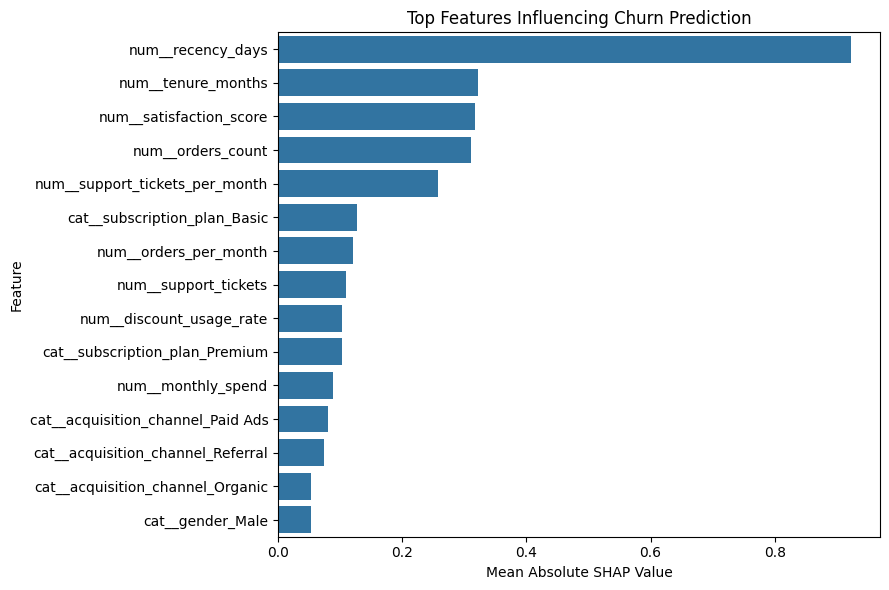

In [ ]:

# Cell 5 — Global SHAP Feature Importance


# Mean absolute SHAP value = average impact of a feature
shap_importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
})

shap_importance = (
    shap_importance
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

# Top 15 features
top_features = shap_importance.head(15)

display(
    top_features.style.format({
        "mean_abs_shap": "{:.4f}"
    })
)

# Visualization
plt.figure(figsize=(9, 6))

sns.barplot(
    data=top_features,
    x="mean_abs_shap",
    y="feature"
)

plt.title("Top Features Influencing Churn Prediction")
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

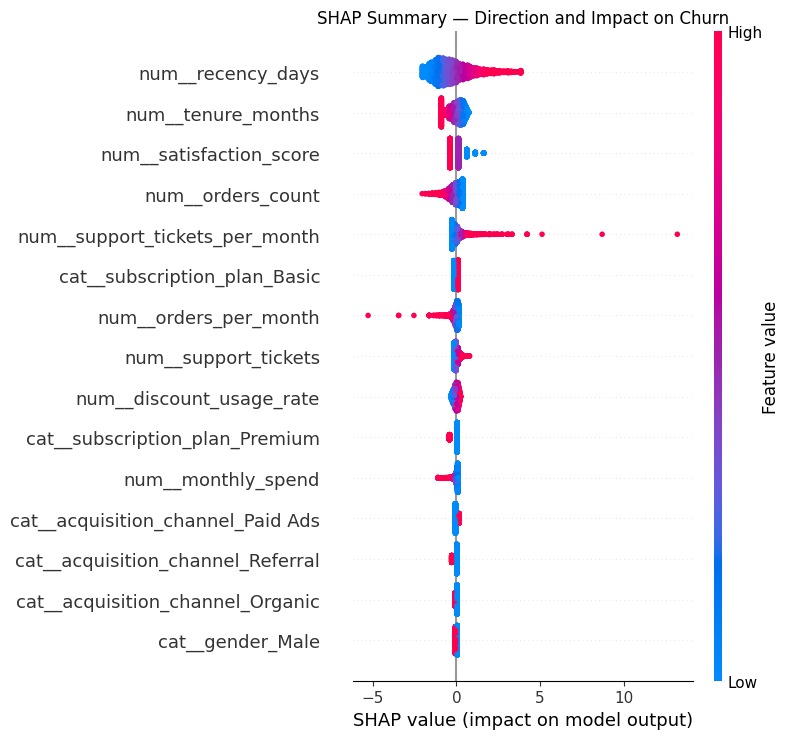

In [ ]:

# Cell 6 — SHAP Beeswarm Plot


plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    max_display=15,
    show=False
)

plt.title("SHAP Summary — Direction and Impact on Churn")
plt.tight_layout()
plt.show()

,feature,mean_abs_shap
0,recency_days,0.9235
1,tenure_months,0.3224
2,satisfaction_score,0.3170
3,orders_count,0.3103
4,support_tickets_per_month,0.2575
5,orders_per_month,0.1215
6,support_tickets,0.1095
7,discount_usage_rate,0.1033
8,monthly_spend,0.0891
9,subscription_plan,0.0848


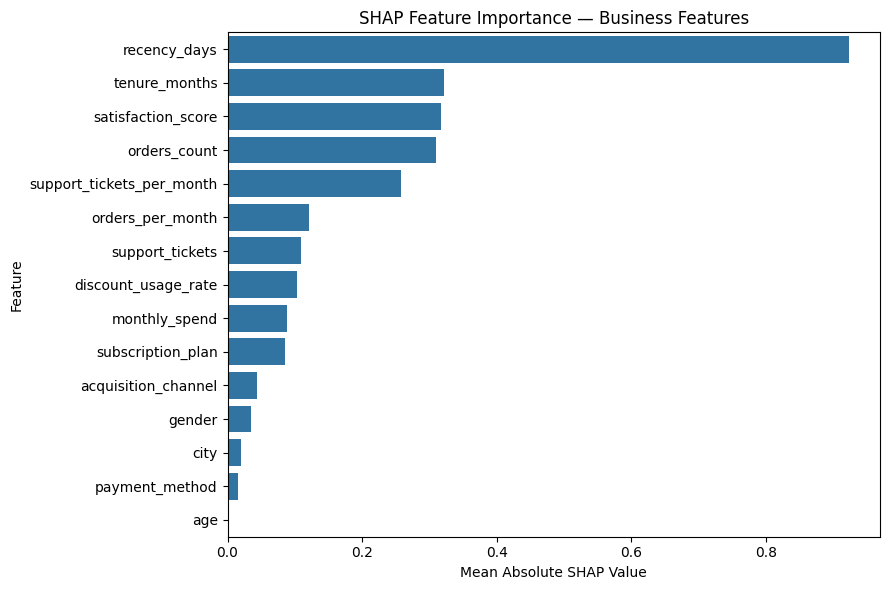

In [ ]:

# Cell 7 — Business-Level SHAP Importance


# Create SHAP importance dataframe
shap_business = pd.DataFrame({
    "transformed_feature": feature_names,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
})

# Map transformed features back to original feature names
def get_original_feature(feature):
    feature = feature.replace("num__", "").replace("cat__", "")
    
    categorical_features = [
        "gender",
        "city",
        "acquisition_channel",
        "subscription_plan",
        "payment_method"
    ]
    
    for cat in categorical_features:
        if feature.startswith(cat + "_"):
            return cat
    
    return feature


shap_business["original_feature"] = (
    shap_business["transformed_feature"]
    .apply(get_original_feature)
)

# Aggregate one-hot encoded features
business_importance = (
    shap_business
    .groupby("original_feature")["mean_abs_shap"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

business_importance.columns = [
    "feature",
    "mean_abs_shap"
]

display(
    business_importance.style.format({
        "mean_abs_shap": "{:.4f}"
    })
)

# Plot
plt.figure(figsize=(9, 6))

sns.barplot(
    data=business_importance,
    x="mean_abs_shap",
    y="feature"
)

plt.title("SHAP Feature Importance — Business Features")
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Customer ID: 153610
Actual Churn: 1
Predicted Churn Probability: 0.9998


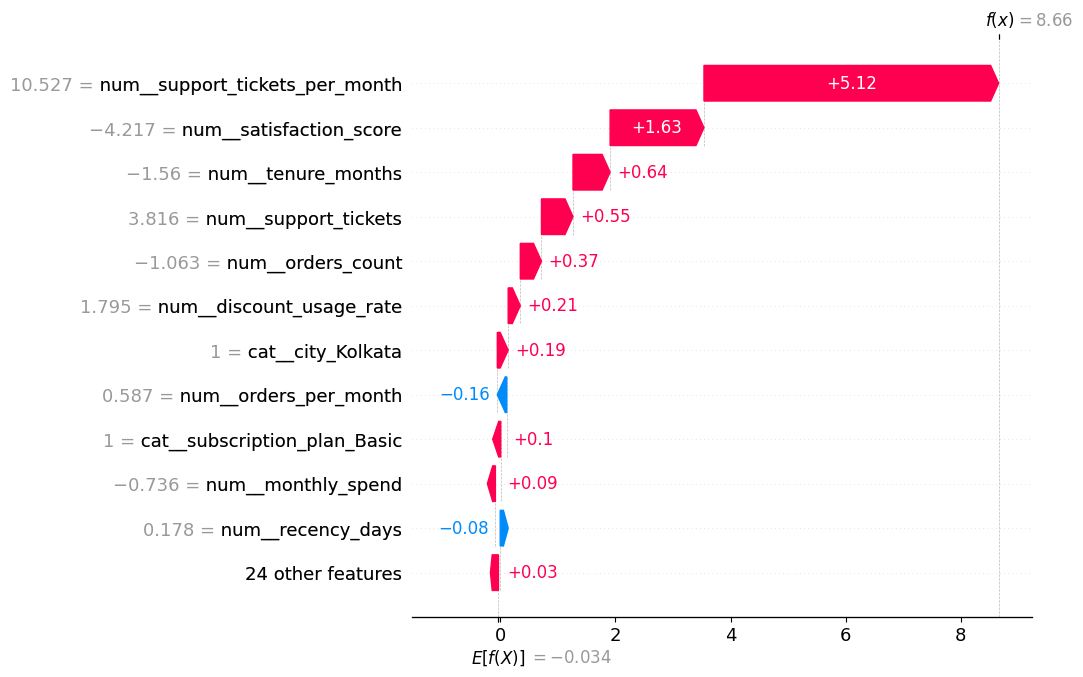

In [ ]:

# Cell 8 — Individual Customer SHAP Explanation


# Get original rows corresponding to the SHAP sample
sample_indices = X_shap.index

X_sample_original = X.loc[sample_indices]

# Predict churn probability
sample_probabilities = final_model.predict_proba(X_sample_original)[:, 1]

# Select the highest-risk customer in the SHAP sample
high_risk_position = np.argmax(sample_probabilities)

customer_index = sample_indices[high_risk_position]
customer_probability = sample_probabilities[high_risk_position]

# Customer information
customer_id = df.loc[customer_index, "customer_id"]
actual_churn = df.loc[customer_index, "churn"]

print("Customer ID:", customer_id)
print("Actual Churn:", actual_churn)
print("Predicted Churn Probability:", round(customer_probability, 4))

# Create SHAP explanation
customer_explanation = shap.Explanation(
    values=shap_values[high_risk_position],
    base_values=explainer.expected_value,
    data=X_shap.iloc[high_risk_position],
    feature_names=feature_names
)

# Waterfall plot
shap.plots.waterfall(
    customer_explanation,
    max_display=12
)